# Exploratory Data Analysis & Prototyping
### AI-Based Data Quality Monitoring System

This notebook walks through the same exploration that motivated the design of
`preprocessing/preprocess.py`, `validation/great_expectations.py`, and
`training/train.py`. It's meant as a readable, browsable companion to the
production pipeline -- the actual pipeline the API/dashboard/Airflow DAG run
lives in the `.py` modules, not here.


In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 20)

DATA_PATH = '../data/raw/synthetic_data.csv'
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (103000, 9)


,CustomerID,Age,Salary,PurchaseAmount,City,Country,TransactionDate,QualityIssue,Label
0,CUST175286,39.0,40208.12,35.95,Chicago,France,2023-11-25,No Issue,Good Data
1,CUST166807,46.0,33230.47,47.64,Dubai,Singapore,2023-08-22,No Issue,Good Data
2,CUST130576,28.0,64621.43,42.32,Berlin,Italy,2024-08-15,No Issue,Good Data
3,CUST145839,48.0,39140.03,176.67,Melbourne,UAE,2025-05-31,No Issue,Good Data
4,CUST195638,41.0,36627.91,120.28,Melbourne,Italy,2025-01-23,No Issue,Good Data


## Data Overview

In [2]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,103000,100000,CUST121465,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,100973.0,NaN,NaN,NaN,41.750577,18.900712,-49.0,32.0,41.0,50.0,299.0
Salary,100918.0,NaN,NaN,NaN,74759.001049,148496.948496,-1909186.645347,37320.3675,52884.59,76140.2125,2127396.262547
PurchaseAmount,101435.0,NaN,NaN,NaN,137.296954,375.173105,-5143.223558,48.595,87.0,141.435,5284.037822
City,101696,32,Paris,4014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,101657,20,Spain,6807,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TransactionDate,101821,1865,0000-00-00,292,NaN,NaN,NaN,NaN,NaN,NaN,NaN
QualityIssue,103000,9,No Issue,81837,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Label,103000,2,Good Data,79285,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing Values

Salary             2.02
Age                1.97
PurchaseAmount     1.52
Country            1.30
City               1.27
TransactionDate    1.14
dtype: float64


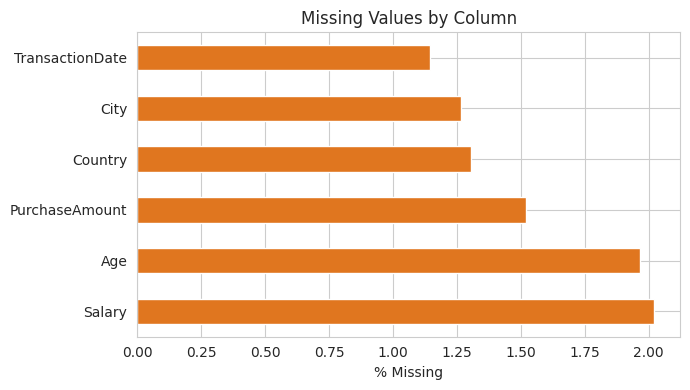

In [3]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
print(missing.round(2))

fig, ax = plt.subplots(figsize=(7,4))
missing.plot(kind='barh', ax=ax, color='#e0761f')
ax.set_xlabel('% Missing')
ax.set_title('Missing Values by Column')
plt.tight_layout()
plt.show()

## Label Distribution
Ground-truth Good Data / Bad Data split (see `data/generate_synthetic_data.py`).

Label
Good Data    79285
Bad Data     23715
Name: count, dtype: int64
Label
Good Data    76.98
Bad Data     23.02
Name: count, dtype: float64


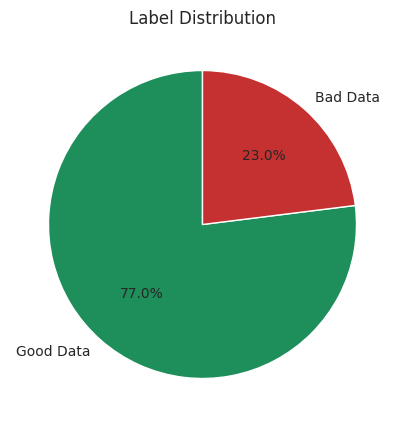

In [4]:
label_counts = df['Label'].value_counts()
print(label_counts)
print((label_counts / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(5,5))
ax.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
       colors=['#1e8e5a', '#c53030'], startangle=90)
ax.set_title('Label Distribution')
plt.show()

## Quality Issue Breakdown
Which injected issue is responsible for each 'Bad Data' row.

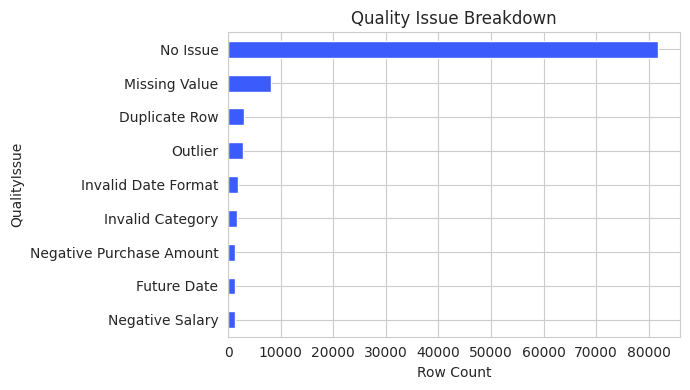

In [5]:
issue_counts = df['QualityIssue'].value_counts()
fig, ax = plt.subplots(figsize=(7,4))
issue_counts.plot(kind='barh', ax=ax, color='#3b5bfd')
ax.invert_yaxis()
ax.set_xlabel('Row Count')
ax.set_title('Quality Issue Breakdown')
plt.tight_layout()
plt.show()

## Duplicate Rows

In [6]:
dup_cols = ['CustomerID','Age','Salary','PurchaseAmount','City','Country','TransactionDate']
dup_rate = df.duplicated(subset=dup_cols).mean() * 100
print(f'Duplicate rows: {dup_rate:.2f}%')

Duplicate rows: 2.91%


## Numeric Distributions & Outliers

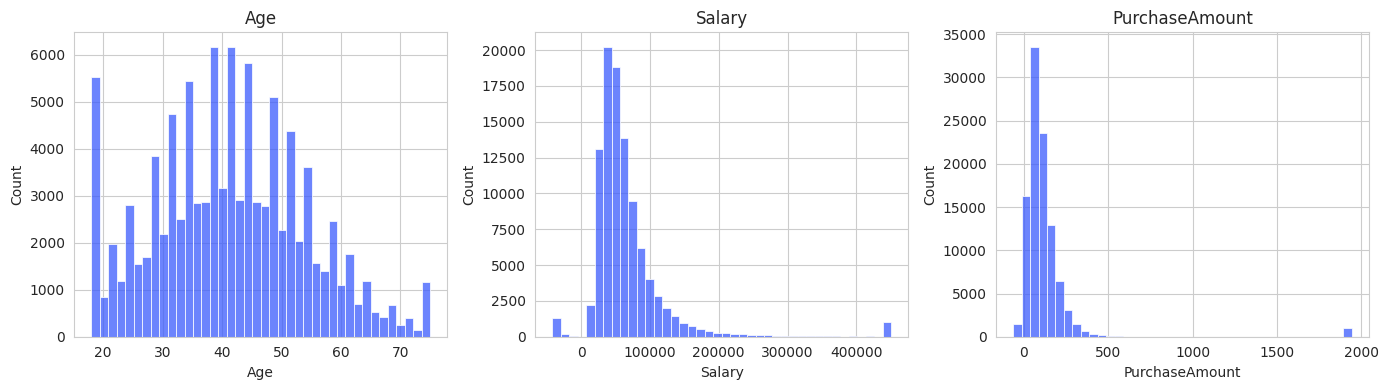

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, col in zip(axes, ['Age', 'Salary', 'PurchaseAmount']):
    vals = pd.to_numeric(df[col], errors='coerce').dropna()
    # clip extreme outliers just for a readable histogram; the pipeline itself
    # (preprocessing/preprocess.py) uses full IQR/z-score logic, not this clip
    clipped = vals.clip(vals.quantile(0.01), vals.quantile(0.99))
    sns.histplot(clipped, ax=ax, bins=40, color='#3b5bfd')
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Data Drift Preview: Reference vs Current Period
The generator shifts `Salary`/`PurchaseAmount` distributions in the most recent ~30% of the time window to simulate real drift -- this is what `monitoring/monitor.py`'s KS-test drift check detects.

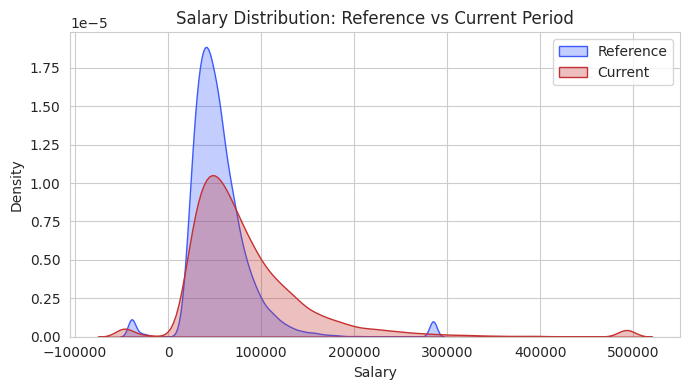

KS statistic: 0.2542  (p-value 0.00e+00)


In [8]:
parsed_dates = pd.to_datetime(df['TransactionDate'], errors='coerce', format='mixed')
cutoff = parsed_dates.quantile(0.70)
reference = df[parsed_dates <= cutoff]
current = df[parsed_dates > cutoff]

fig, ax = plt.subplots(figsize=(7,4))
for name, data, color in [('Reference', reference, '#3b5bfd'), ('Current', current, '#c53030')]:
    vals = pd.to_numeric(data['Salary'], errors='coerce').dropna()
    vals = vals.clip(vals.quantile(0.01), vals.quantile(0.99))
    sns.kdeplot(vals, ax=ax, label=name, color=color, fill=True, alpha=0.3)
ax.set_title('Salary Distribution: Reference vs Current Period')
ax.legend()
plt.tight_layout()
plt.show()

from scipy.stats import ks_2samp
ks_stat, p_value = ks_2samp(
    pd.to_numeric(reference['Salary'], errors='coerce').dropna(),
    pd.to_numeric(current['Salary'], errors='coerce').dropna(),
)
print(f'KS statistic: {ks_stat:.4f}  (p-value {p_value:.2e})')

## Feature Engineering Preview
Reusing the actual `preprocessing.preprocess` module (not a notebook-only reimplementation).

In [9]:
from preprocessing.preprocess import compute_reference_stats, engineer_features

reference_stats = compute_reference_stats(reference)
features = engineer_features(df, reference_stats)
print(f'Engineered {features.shape[1]} features for {features.shape[0]:,} rows, zero NaNs: {features.isna().sum().sum() == 0}')
features.head()

Engineered 24 features for 103,000 rows, zero NaNs: True


,missing_ratio,age_missing,salary_missing,purchase_missing,city_missing,country_missing,date_missing,is_duplicate,age_zscore,salary_zscore,...,outlier_score,is_valid_date,is_future_date,days_since_transaction,rolling_avg_purchase_7,schema_violation_count,city_valid,country_valid,negative_salary_flag,negative_purchase_flag
0,0.0,0,0,0,0,0,0,0,-0.147618,-0.180440,...,0.255280,1,0,949.0,721.803335,0,1,1,0,0
1,0.0,0,0,0,0,0,0,0,0.220605,-0.228220,...,0.228220,1,0,1044.0,110.418571,0,1,1,0,0
2,0.0,0,0,0,0,0,0,0,-0.726253,-0.013268,...,0.726253,1,0,685.0,144.497143,0,1,1,0,0
3,0.0,0,0,0,0,0,0,0,0.325811,-0.187754,...,0.325811,1,0,396.0,102.566000,0,1,1,0,0
4,0.0,0,0,0,0,0,0,0,-0.042411,-0.204956,...,0.204956,1,0,524.0,78.444286,0,1,1,0,0


## Quick Baseline Model Prototype
A fast, small-scale sanity check before committing to the full GridSearchCV pipeline in `training/train.py` (which trains on the full dataset with proper leak-safe reference-stat fitting, hyperparameter search, and cross-validation).

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

y = df['Label'].map({'Good Data': 0, 'Bad Data': 1})
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.2, random_state=42, stratify=y)

baseline = RandomForestClassifier(n_estimators=80, max_depth=10, random_state=42, class_weight='balanced', n_jobs=1)
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Good Data', 'Bad Data']))

              precision    recall  f1-score   support

   Good Data       0.93      0.98      0.95     15857
    Bad Data       0.90      0.75      0.82      4743

    accuracy                           0.92     20600
   macro avg       0.91      0.86      0.88     20600
weighted avg       0.92      0.92      0.92     20600



## Next Steps

This baseline is intentionally quick and rough. The production pipeline in `training/train.py`:

- Fits reference statistics on the **train split only** (no leakage)
- Runs **GridSearchCV** + **k-fold cross-validation** for both RandomForest and XGBoost
- Also trains an **Isolation Forest** anomaly detector
- Saves models, metrics, and diagnostic plots (`docs/images/`) used by the README and dashboard

See `README.md` for the full architecture, or run:

```bash
python training/train.py
streamlit run dashboard/dashboard.py
uvicorn api.app:app --reload
```
